<a href="https://colab.research.google.com/github/praveenbunker/data-science-project/blob/main/Movie_Popularity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Movie Data Analysis

This project explores a movie dataset using Python, Pandas, Matplotlib, and Seaborn.  
The analysis focuses on genres, vote categories, popularity, and release-year trends.

## Project questions

1. Which genres appear most frequently?
2. Which vote category has the highest number of movies?
3. Which movies are the most and least popular?
4. Which years had the highest number of movie releases?
5. Is there any relationship between popularity, vote count, and vote average?


## Phase-1: Importing Modules and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("mymoviedb.csv", lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


## Phase 2 — Initial data inspection

In [ ]:
print("Shape:",df.shape)
df.info()

Shape: (9827, 9)
<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [ ]:
df['Genre'].head() # in order to find the types of genre being used in the dataset

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.describe())

        Popularity    Vote_Count  Vote_Average
count  9827.000000   9827.000000   9827.000000
mean     40.326088   1392.805536      6.439534
std     108.873998   2611.206907      1.129759
min      13.354000      0.000000      0.000000
25%      16.128500    146.000000      5.900000
50%      21.199000    444.000000      6.500000
75%      35.191500   1376.000000      7.100000
max    5083.954000  31077.000000     10.000000


In [ ]:
# Release-Date datatype/format needs to be changed
# white spaces between the Genre types may or may not needed to be removed
# dropping down the columns that needs not analysis(like-overview, language and poster url)
# All of these things needs to be done in the data preprocessing.
# Insights gained till now-


### Exploratory summary
- we have a dataframe consisting of 9827 entries and 9 columns.
- our dataset looks a bit tidy with no NaNs or duplicated values.
- Release_Date column need to be casted into date time and to extract only the year value.
- Overview, Original_Language and Poster-Url wouldn't be so useful during analysis, so we'll drop them.
- There is noticable outliers in the Popularity column.
- Vote_Average better be categorised for proper analysis.
- Genre column has comma separated values and white spaces that needs to be handled and casted into category.

### Phase-3: Cleaning Data and Preprocessing

In [ ]:
# changing the date time format of the Release_Date column

df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

datetime64[us]


dtype('int32')

In [ ]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


#### Dropping down the irrelevant columns

In [ ]:
# Overview, Original_Language, Poster_Url column to be dropped

cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis = 1, inplace = True)
df.columns


Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


#### **Categorizing** `Vote_Average` column  
We would cut the `Vote_Average` values and make 4 categories `popular`,`average`, `below_avg` , `not_popular` to describe it more using categorize_col() function provided

In [ ]:
# creating a user defined function to label the popularity of the movie

def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df

In [ ]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [ ]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [ ]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


# Phase 4 — Linear Regression Model

In [ ]:
df_ml = df.copy()
df_ml.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [ ]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 9727 entries, 0 to 9826
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  9727 non-null   int32   
 1   Title         9727 non-null   str     
 2   Popularity    9727 non-null   float64 
 3   Vote_Count    9727 non-null   int64   
 4   Vote_Average  9727 non-null   category
 5   Genre         9727 non-null   str     
dtypes: category(1), float64(1), int32(1), int64(1), str(2)
memory usage: 427.7 KB


## Feature Selection

In [ ]:
# Removing unnecessary columns

df_ml = df_ml.drop(columns=['Title'])

df_ml.head()

,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,2021,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,2618.087,122,below_avg,Thriller
3,2021,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [ ]:
## Checking Data Types
df_ml.dtypes

Release_Date       int32
Popularity       float64
Vote_Count         int64
Vote_Average    category
Genre                str
dtype: object

In [ ]:
## Encoding Vote Average
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_ml['Vote_Average'] = le.fit_transform(df_ml['Vote_Average'])
df_ml.head()

,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,2021,5083.954,8940,3,"Action, Adventure, Science Fiction"
1,2022,3827.658,1151,3,"Crime, Mystery, Thriller"
2,2022,2618.087,122,1,Thriller
3,2021,2402.201,5076,3,"Animation, Comedy, Family, Fantasy"
4,2021,1895.511,1793,0,"Action, Adventure, Thriller, War"


In [ ]:
print(le.classes_)

['average' 'below_avg' 'not_popular' 'popular']


## Final Feature Selection

In [ ]:
# Removing Genre column for the first model

df_ml = df_ml.drop(columns = ['Genre'])

df_ml.head()

,Release_Date,Popularity,Vote_Count,Vote_Average
0,2021,5083.954,8940,3
1,2022,3827.658,1151,3
2,2022,2618.087,122,1
3,2021,2402.201,5076,3
4,2021,1895.511,1793,0


# Phase 5 - Splitting Features and Targets

In [ ]:
# Features (Independent Variables)
X = df_ml.drop(columns=['Popularity'])

# Target (Dependent Variable)
y = df_ml['Popularity']

print("Features:")
display(X.head())

print('\nTarget:')
display(y.head())

Features:


,Release_Date,Vote_Count,Vote_Average
0,2021,8940,3
1,2022,1151,3
2,2022,122,1
3,2021,5076,3
4,2021,1793,0



Target:


0    5083.954
1    3827.658
2    2618.087
3    2402.201
4    1895.511
Name: Popularity, dtype: float64

In [ ]:
print('Shape of X :', X.shape)
print('Shape of y:', y.shape)

Shape of X : (9727, 3)
Shape of y: (9727,)


# Phase 6 — Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [ ]:
print('Training Features :', X_train.shape)
print('Testing Features :', X_test.shape)

print()

print('Training Target :', y_train.shape)
print('Testing Target :', y_test.shape)

print("Model trained successfully!")


Training Features : (7781, 3)
Testing Features : (1946, 3)

Training Target : (7781,)
Testing Target : (1946,)
Model trained successfully!


# Phase 7 — Training the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.8 ,0.01,0.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Release_Date','Vote_Count','Vote_Average']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1577
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


# Phase 8 — Making Predictions

In [ ]:
# Predicting popularity using test data

y_pred = model.predict(X_test)

print("First 10 predictions:\n")
print(y_pred[:10])

First 10 predictions:

[37.75332888 40.45607672 43.56751553 27.58971875 57.89738518 46.16981961
 -6.3236441  44.34189135 28.82495137 36.85687102]


In [ ]:
prediction_df = X_test.copy()

prediction_df['Actual_Popularity'] = y_test
prediction_df['Predicted_Popularity'] = y_pred

prediction_df = prediction_df.round(2)
prediction_df.head(10)

,Release_Date,Vote_Count,Vote_Average,Actual_Popularity,Predicted_Popularity
1159,2008,840,2,59.45,37.75
4389,2004,1997,2,23.00,40.46
5722,2000,3152,3,19.10,43.57
1625,1979,3319,3,47.54,27.59
3496,2015,3768,1,26.96,57.90
120,2022,455,0,246.65,46.17
5700,1958,220,0,19.16,-6.32
1473,2021,254,0,51.10,44.34
7701,1996,1139,0,15.67,28.82
3207,2000,2002,1,28.77,36.86


# Phase 9 — Model Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 33.50
Mean Squared Error: 24984.54
Root Mean Squared Error: 158.06
R2 Score: 0.03


In [ ]:
print(df.columns)
df_ml.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')


Index(['Release_Date', 'Popularity', 'Vote_Count', 'Vote_Average'], dtype='str')

In [ ]:
df_ml_v2 = df.copy()

df_ml_v2 = df_ml_v2.drop(columns=['Title'])

df_ml_v2.head()

,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,2021,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,2618.087,122,below_avg,Thriller
3,2021,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [ ]:
df_ml_v2['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

## Encoding Genre column

In [ ]:
genre_encoded = df_ml_v2['Genre'].str.get_dummies(sep=', ')
genre_encoded.head(10)

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
5,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
8,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_ml_v2 = pd.concat([df_ml_v2, genre_encoded], axis=1)

df_ml_v2 = df_ml_v2.drop(columns=['Genre'])

df_ml_v2.head()

,Release_Date,Popularity,Vote_Count,Vote_Average,Action,Adventure,Animation,Comedy,Crime,Documentary,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,2021,5083.954,8940,popular,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2022,3827.658,1151,popular,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
2,2022,2618.087,122,below_avg,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2021,2402.201,5076,popular,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021,1895.511,1793,average,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [ ]:
df_ml_v2.shape

(9727, 23)

# Phase 11 — Improved Linear Regression Model

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_v2 = LabelEncoder()

df_ml_v2['Vote_Average'] = le_v2.fit_transform(df_ml_v2['Vote_Average'])

df_ml_v2.head()

,Release_Date,Popularity,Vote_Count,Vote_Average,Action,Adventure,Animation,Comedy,Crime,Documentary,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,2021,5083.954,8940,3,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2022,3827.658,1151,3,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
2,2022,2618.087,122,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2021,2402.201,5076,3,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021,1895.511,1793,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [ ]:
X_v2 = df_ml_v2.drop(columns=['Popularity'])

y_v2 = df_ml_v2['Popularity']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model_v2 = LinearRegression()

model_v2.fit(X_train_v2, y_train_v2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[ 0.82, 0. , 0.91,..., 1.92,10.32,10.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['Release_Date','Vote_Count','Vote_Average',...,'Thriller','War','Western']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1609
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)


In [ ]:
y_pred_v2 = model_v2.predict(X_test_v2)

In [ ]:
# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
mse_v2 = mean_squared_error(y_test_v2, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print(f"MAE  : {mae_v2:.2f}")
print(f"MSE  : {mse_v2:.2f}")
print(f"RMSE : {rmse_v2:.2f}")
print(f"R²   : {r2_v2:.4f}")

MAE  : 33.48
MSE  : 24810.99
RMSE : 157.52
R²   : 0.0320


In [ ]:
df.describe()

,Release_Date,Popularity,Vote_Count
count,9727.000000,9727.000000,9727.000000
mean,2006.047805,40.350022,1407.124499
std,15.685268,109.331644,2620.754808
min,1902.000000,13.354000,1.000000
25%,2000.000000,16.120000,152.000000
50%,2011.000000,21.188000,454.000000
75%,2017.000000,35.204500,1393.500000
max,2022.000000,5083.954000,31077.000000


In [ ]:
df[['Popularity', 'Vote_Count']].describe()

,Popularity,Vote_Count
count,9727.000000,9727.000000
mean,40.350022,1407.124499
std,109.331644,2620.754808
min,13.354000,1.000000
25%,16.120000,152.000000
50%,21.188000,454.000000
75%,35.204500,1393.500000
max,5083.954000,31077.000000


## Distribution Analysis

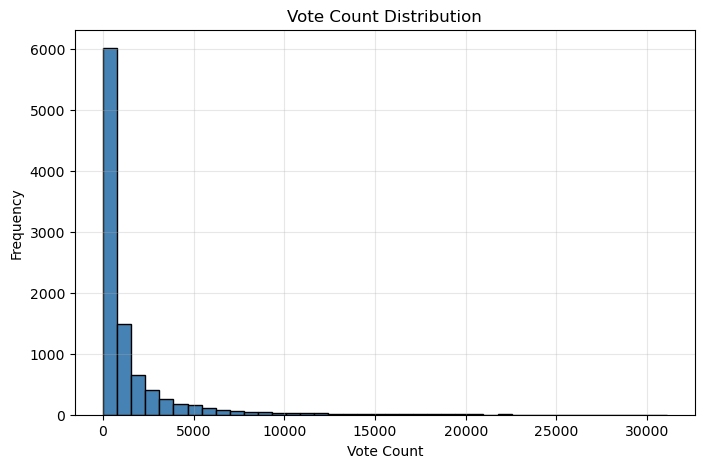

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Vote_Count'], bins=40,
         color='steelblue',
         edgecolor='black')
plt.title("Vote Count Distribution")
plt.xlabel("Vote Count")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

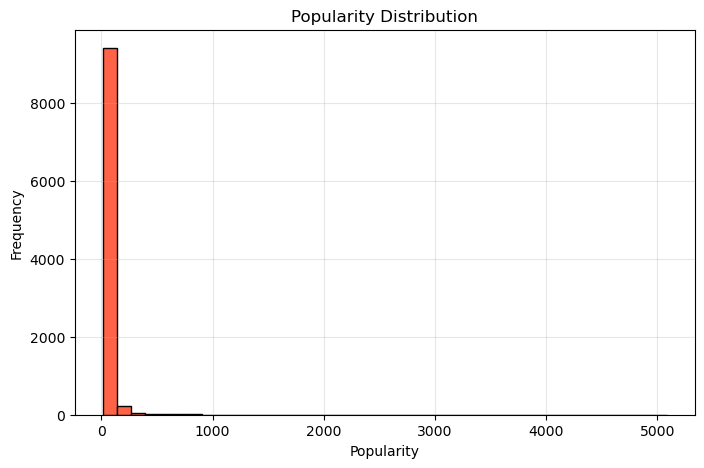

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Popularity'], bins=40,
         color='tomato',
         edgecolor='black')

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

## Log Transformation on Vote Count

In [ ]:
df_ml_v3 = df_ml_v2.copy()

df_ml_v3['Vote_Count'] = np.log1p(df_ml_v3['Vote_Count'])

df_ml_v3[['Vote_Count']].head()

,Vote_Count
0,9.098403
1,7.049255
2,4.812184
3,8.532476
4,7.492203


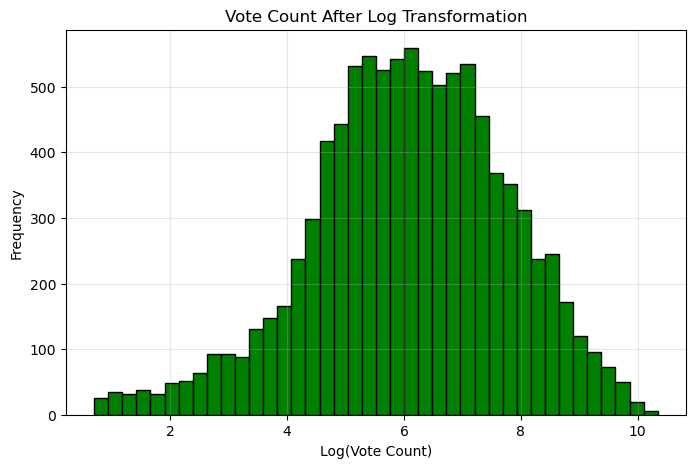

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df_ml_v3['Vote_Count'],
         bins=40,
         color='green',
         edgecolor='black')

plt.title("Vote Count After Log Transformation")
plt.xlabel("Log(Vote Count)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
X_v3 = df_ml_v3.drop(columns=['Popularity'])
y_v3 = df_ml_v3['Popularity']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train_v3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[ 0.89, 4.93, 2.12,...,-0.18,10.54, 9.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['Release_Date','Vote_Count','Vote_Average',...,'Thriller','War','Western']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1783
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)


In [ ]:
y_pred_v3 = model_v3.predict(X_test_v3)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)
mse_v3 = mean_squared_error(y_test_v3, y_pred_v3)
rmse_v3 = np.sqrt(mse_v3)
r2_v3 = r2_score(y_test_v3, y_pred_v3)

print(f"MAE  : {mae_v3:.2f}")
print(f"MSE  : {mse_v3:.2f}")
print(f"RMSE : {rmse_v3:.2f}")
print(f"R²   : {r2_v3:.4f}")

MAE  : 34.65
MSE  : 24941.86
RMSE : 157.93
R²   : 0.0269


In [ ]:
df_ml_v3.dtypes

Release_Date         int32
Popularity         float64
Vote_Count         float64
Vote_Average         int64
Action               int64
Adventure            int64
Animation            int64
Comedy               int64
Crime                int64
Documentary          int64
Drama                int64
Family               int64
Fantasy              int64
History              int64
Horror               int64
Music                int64
Mystery              int64
Romance              int64
Science Fiction      int64
TV Movie             int64
Thriller             int64
War                  int64
Western              int64
dtype: object

## Experiment 1 — Baseline Linear Regression

Features Used:
- Release_Date
- Vote_Count
- Vote_Average

Results:
- MAE  : 33.50
- MSE  : 24984.54
- RMSE : 158.06
- R²   : 0.0300

### Insight
The baseline model was trained using three numerical features. Although the model was able to make predictions, the R² score indicates that these features explain only a small portion of the variation in movie popularity.

## Experiment 2 — Genre Encoding

Changes Made:
- One-Hot Encoded the Genre column.
- Retained the original Vote_Count values.

Results:
- MAE  : 33.48
- MSE  : 24810.99
- RMSE : 157.52
- R²   : 0.0320

### Insight
Adding genre information provided a slight improvement in model performance. This suggests that genre contributes to movie popularity, although its impact is limited when used with a Linear Regression model.

## Experiment 3 — Log Transformation

Changes Made:
- Applied Log Transformation on Vote_Count.
- Used the Genre Encoded dataset.

Results:
- MAE  : 34.65
- MSE  : 24941.86
- RMSE : 157.93
- R²   : 0.0269

### Insight
Although the log transformation normalized the Vote_Count distribution, it did not improve the model performance. Therefore, this preprocessing step was not retained in the final model.

In [ ]:
comparison = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "Genre Encoding",
        "Genre + Log Transform"
    ],
    "MAE": [33.50, 33.48, 34.65],
    "RMSE": [158.06, 157.52, 157.93],
    "R² Score": [0.0300, 0.0320, 0.0269]
})

comparison

,Experiment,MAE,RMSE,R² Score
0,Baseline,33.50,158.06,0.0300
1,Genre Encoding,33.48,157.52,0.0320
2,Genre + Log Transform,34.65,157.93,0.0269


# Conclusion

This project explored the use of Linear Regression to predict movie popularity using the available Netflix movie dataset.

Three different experiments were performed to improve the model:
1. Baseline Linear Regression
2. Genre Encoding
3. Log Transformation of Vote_Count

Among these, Genre Encoding produced the best results and was selected as the final model.

Despite multiple preprocessing experiments, the R² score remained relatively low. This indicates that movie popularity is influenced by additional factors that are not present in the dataset or that the relationship between the available features and popularity is not purely linear.

Future improvements may include:
- Collecting additional movie-related features.
- Performing more advanced feature engineering.
- Experimenting with non-linear machine learning models such as Decision Tree Regressor or Random Forest Regressor.

# Final Model Selection

After evaluating all the experiments, **Experiment 2 (Genre Encoding)** was selected as the final model because it achieved the best predictive performance among all Linear Regression models.

### Comparison of Experiments

| Experiment | MAE | RMSE | R² Score |
|------------|-----:|------:|---------:|
| Baseline Model | 33.50 | 158.06 | 0.0300 |
| Genre Encoding | **33.48** | **157.52** | **0.0320** |
| Genre + Log Transformation | 34.65 | 157.93 | 0.0269 |

**Selected Model:** Experiment 2 (Genre Encoding)

In [ ]:
# Final Selected Model

final_model = model_v2

X_train_final = X_train_v2
X_test_final = X_test_v2

y_train_final = y_train_v2
y_test_final = y_test_v2

y_pred_final = y_pred_v2

In [ ]:
print("Final Model Selected Successfully!")
print(final_model)

Final Model Selected Successfully!
LinearRegression()


In [ ]:
print(f"Final R² Score : {r2_v2:.4f}")
print(f"Final RMSE     : {rmse_v2:.2f}")
print(f"Final MAE      : {mae_v2:.2f}")

Final R² Score : 0.0320
Final RMSE     : 157.52
Final MAE      : 33.48


# Final Model Visualization

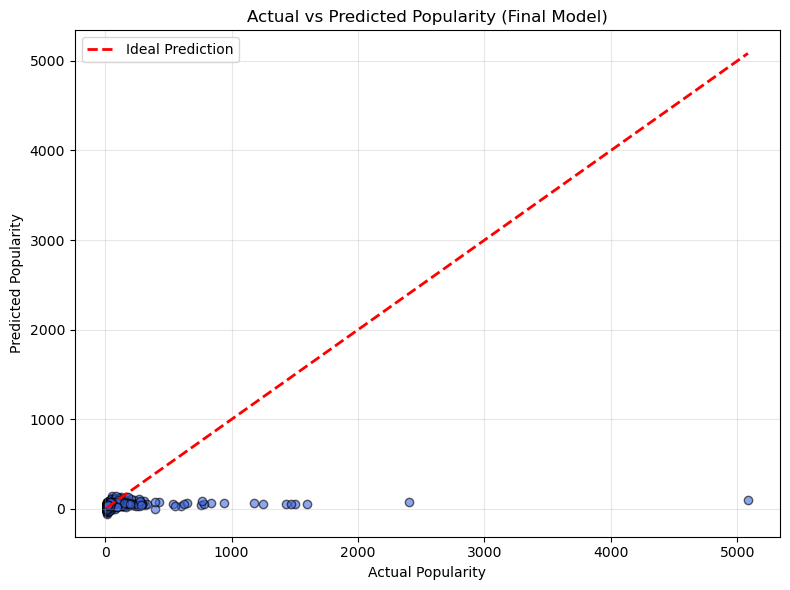

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_final,
    y_pred_final,
    alpha=0.6,
    color='royalblue',
    edgecolors='black'
)

plt.plot(
    [y_test_final.min(), y_test_final.max()],
    [y_test_final.min(), y_test_final.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.title("Actual vs Predicted Popularity (Final Model)")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/final_model_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

# Final Conclusion

The objective of this project was to predict movie popularity using Linear Regression.

Three different experiments were performed to improve the model:

- Baseline Linear Regression
- Genre Encoding
- Log Transformation

Among these experiments, Genre Encoding achieved the highest R² score and was selected as the final model.

Although the final model successfully completed the prediction pipeline, the low R² score indicates that the available features are insufficient to accurately predict movie popularity using a linear relationship.

This project demonstrates the complete machine learning workflow, including:

- Data Cleaning
- Feature Engineering
- Encoding
- Model Training
- Model Evaluation
- Experimentation
- Model Selection

Future improvements may include:

- Collecting additional movie-related features
- Applying advanced feature engineering
- Using non-linear regression algorithms such as Decision Tree Regressor or Random Forest Regressor

## Final Prediction Results

The table below compares the actual popularity values with the values predicted by the final Linear Regression model.

In [ ]:
prediction_result = pd.DataFrame({
    "Actual Popularity": y_test_final,
    "Predicted Popularity": y_pred_final
})

prediction_result = prediction_result.round(2)

prediction_result.head(10)

,Actual Popularity,Predicted Popularity
1159,59.45,40.64
4389,23.00,44.41
5722,19.10,31.52
1625,47.54,17.38
3496,26.96,60.60
120,246.65,38.03
5700,19.16,-2.09
1473,51.10,48.10
7701,15.67,24.00
3207,28.77,50.74
